In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [8]:
df_5fish = pd.read_csv('../data/5/exp05H20140926_10h50.csv')

print(df_5fish)

              X1          Y1         H1        X2         Y2          H2  \
0       278.7222   16.572670  -14.08937  267.4200  -31.96604    4.515203   
1       279.0692   13.679060  -14.09328  266.5200  -37.23983    4.514282   
2       279.1677    9.547691  -14.21702  265.4542  -42.93462    4.515281   
3       279.0923    5.992251  -14.35311  264.4698  -47.36988    4.503917   
4       278.7081    1.236450  -14.25071  263.7570  -51.60890    4.502401   
...          ...         ...        ...       ...        ...         ...   
162824  140.9772 -302.182900 -492.70780  220.9656 -210.70620 -523.871900   
162825  138.7865 -303.449300 -492.71380  218.6858 -213.16260 -523.879300   
162826  136.3163 -304.816500 -492.71780  216.0147 -215.75590 -523.882600   
162827  133.1972 -306.642200 -492.72460  213.2572 -218.45710 -523.896800   
162828  131.1287 -307.698600 -492.73790  210.4540 -221.17990 -523.902900   

              X3        Y3        H3        X4         Y4          H4  \
0       236.47

In [15]:
n_fish = 5
positions = {}

In [20]:
all_x = []
all_y = []

for f in range(1, n_fish+1):
    all_x.append(df_5fish[f'X{f}'].dropna().values)
    all_y.append(df_5fish[f'Y{f}'].dropna().values)

all_x = np.concatenate(all_x)
all_y = np.concatenate(all_y)

centre_x = np.nanmean(all_x)
centre_y = np.nanmean(all_y)
print(f'estimated cnetre= ({centre_x}, {centre_y}) pixels')

# distance of every point from the centre
r = np.sqrt((all_x - centre_x)**2 + (all_y - centre_y)**2)

# outer wall approx= furthest fish ever reach
outer_radius_px = np.percentile(r, 99)   # 99th percentile avoids outliers
inner_radius_px = np.percentile(r, 1)    # 1st percentile for inner wall

print(f'estimated outer radius = {outer_radius_px}')
print(f'estimated inner radius = {inner_radius_px}')

outer_radius_real_mm = 350   # 35 cm
inner_radius_real_mm = 250   # 25 cm

px_to_mm_outer = outer_radius_real_mm / outer_radius_px
px_to_mm_inner = inner_radius_real_mm / inner_radius_px

# average of both estimates
px_to_mm = np.mean([px_to_mm_outer, px_to_mm_inner])
px_to_cm  = px_to_mm / 10

print(f'final calibration: 1px = {px_to_mm} mm = {px_to_cm}cm')

estimated cnetre= (-30.599226998429177, -30.768485826913338) pixels
estimated outer radius = 379.7062940048594
estimated inner radius = 221.25374866900935
final calibration: 1px = 1.0258447159285877 mm = 0.10258447159285877cm


In [23]:
for i in range(1, n_fish +1):
    positions[i] = df_5fish[[f'X{i}', f'Y{i}']].values # shape (T, 2)

positions_array = np.stack([positions[i] for i in range(1, n_fish +1)], axis=1)
# positions_array[t, f, :] = [x, y] of fish f at time t

# centre of neihgbours for each fish 
def centre_of_neighbours(positions_array):
    '''
    for each fish at each time step finding the mean
    position for all other visible (not nan) fish
    '''
    t, n, _ = positions_array.shape
    centres = np.full((t, n, 2), np.nan)
    n_neighbours = np.zeros((t, n), dtype=int)

    for f in range(n):
        # mask of all other fish - shape (t, n-1, 2)
        otherfish_idx = [j for j in range(n) if j != f]
        otherfish = positions_array[:, otherfish_idx, :] # (t, n-1, 2)

        # nan mean across fish axis - (t, 2)
        with np.errstate(all='ignore'):
            centres[:, f, :] = np.nanmean(otherfish, axis=1)

        # counting visible neighbours at each timestep
        visible_fish = ~np.isnan(otherfish[:, :, 0])
        n_neighbours[:, f] = visible_fish.sum(axis=1)

    return centres, n_neighbours

centres, n_neighbours = centre_of_neighbours(positions_array)

# cohesion vector
cohesion_vector = centres - positions_array
cohesion_distance = np.linalg.norm(cohesion_vector, axis=2)
cohesion_distance_cm = cohesion_distance * px_to_cm


print('cohesion distance - mean per fish (pixels):')
for f in range(n_fish):
    print(f'fish {f+1} = {np.nanmean(cohesion_distance[:, f])}')

print('cohesion distance - mean per fish (cm):')
for f in range(n_fish):
    print(f'fish {f+1} = {np.nanmean(cohesion_distance_cm[:, f])} cm')

cohesion distance - mean per fish (pixels):
fish 1 = 69.53211077346302
fish 2 = 48.6216705582946
fish 3 = 67.9680656642869
fish 4 = 54.254861277836966
fish 5 = 48.06996053969959
cohesion distance - mean per fish (cm):
fish 1 = 7.132914842431827 cm
fish 2 = 4.987828382184711 cm
fish 3 = 6.972468101359598 cm
fish 4 = 5.56570627553076 cm
fish 5 = 4.931231501454655 cm


C:\Users\alice\AppData\Local\Temp\ipykernel_3204\1967834114.py:24: RuntimeWarning: Mean of empty slice
  centres[:, f, :] = np.nanmean(otherfish, axis=1)


What I've done: 
* At each time step I have found all the other fish (ignored the current fish itself)
* Calculated the mean position of those other fish - neighbour centre
* Measured the distance from that fish to that neighbour centre
* Averaged the distance across all time steps

The distances shown are those of the fish to the centre of the other 4 fish. Fish 2 and 5 seem to be the clossest to the centre. 

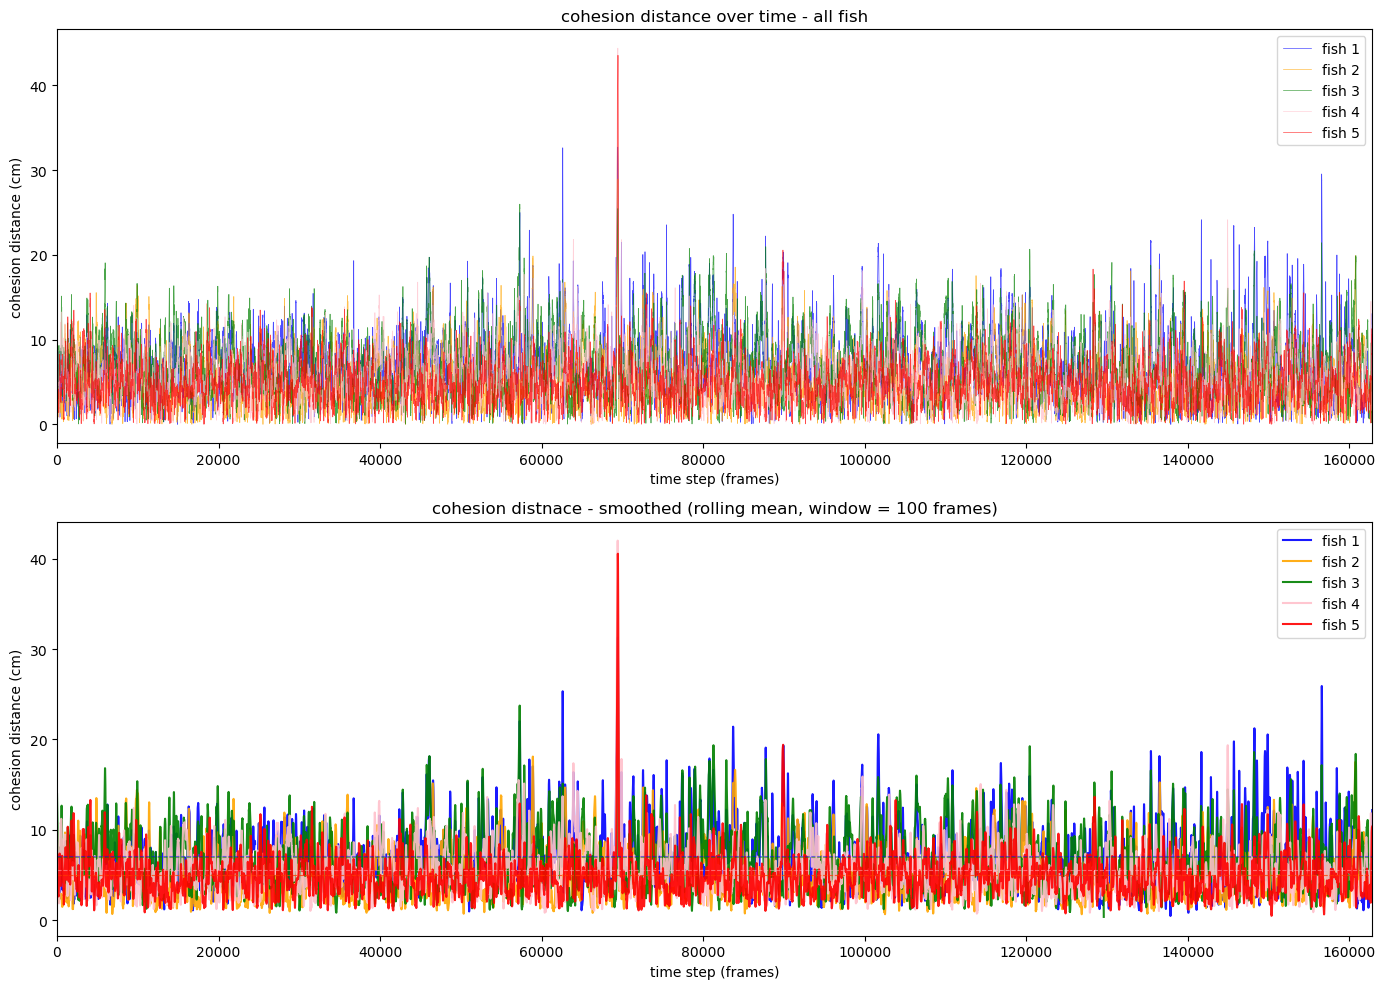

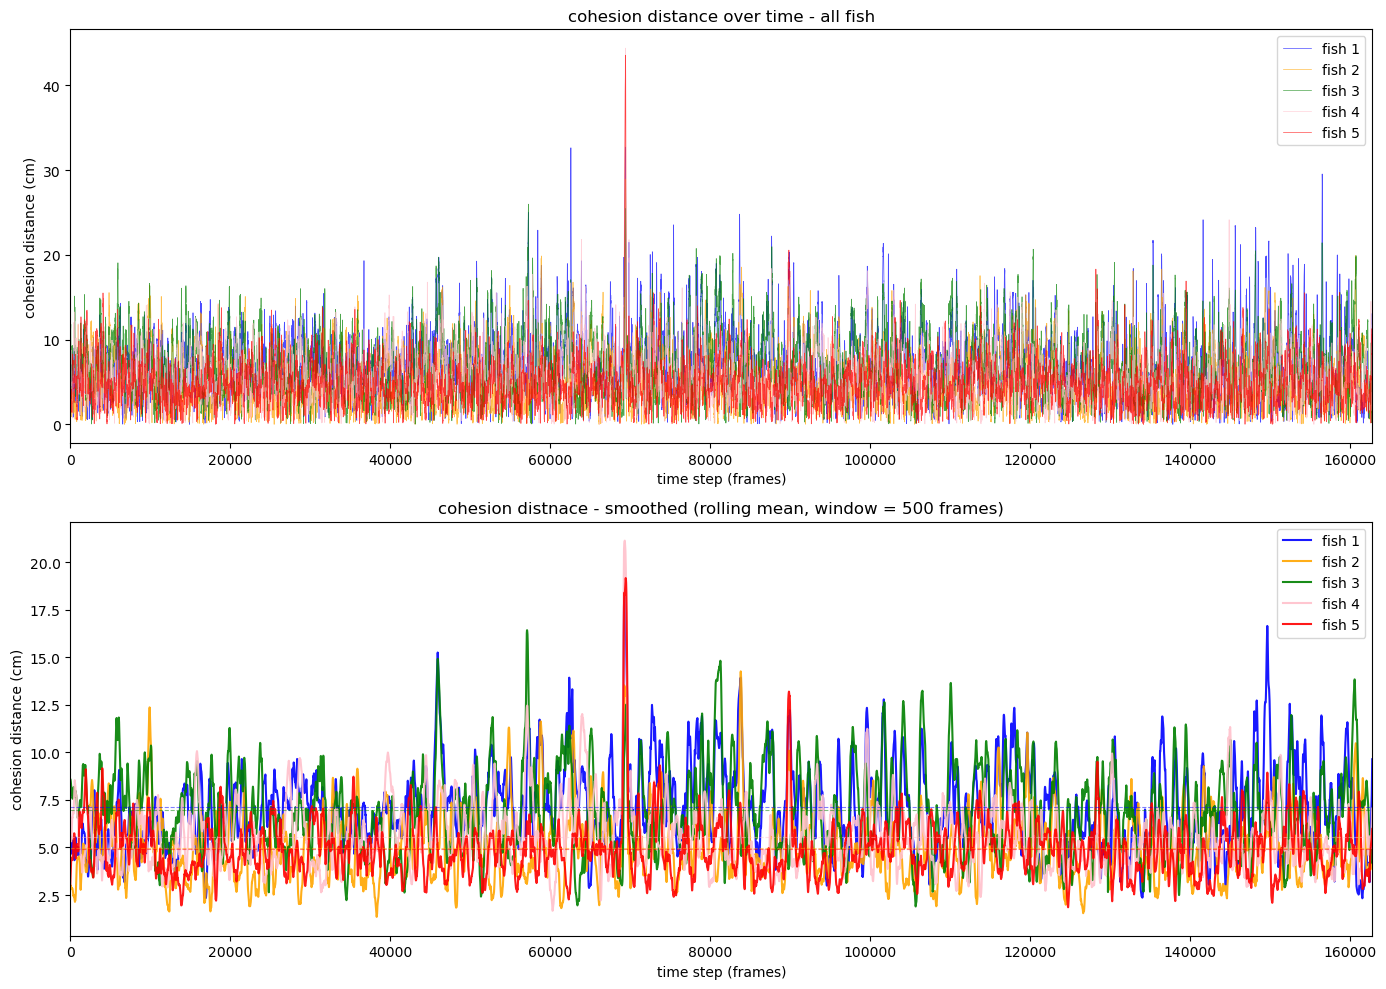

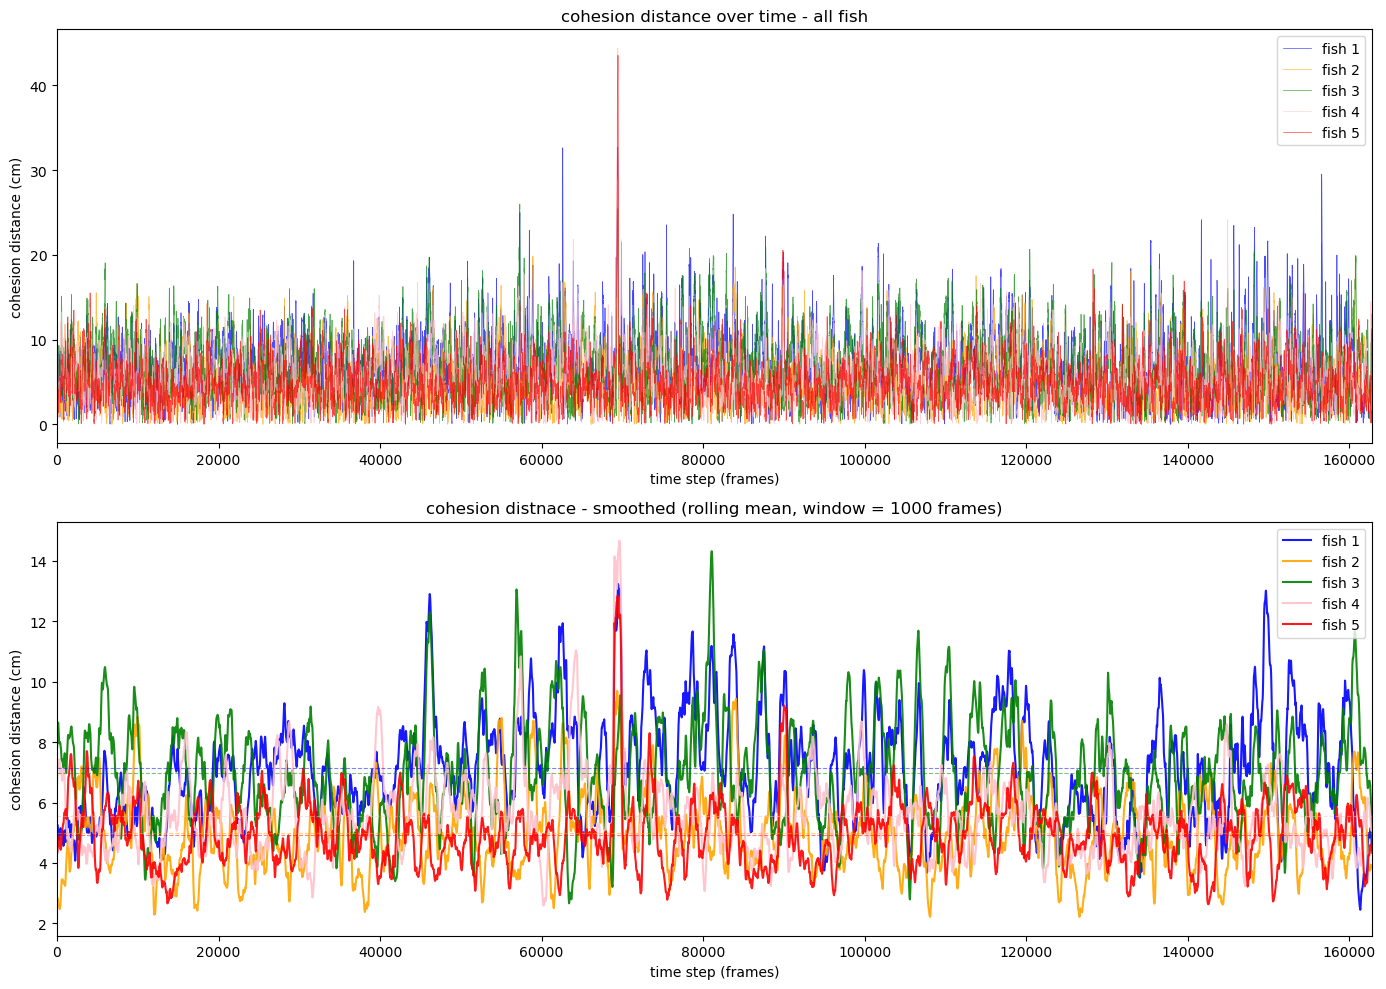

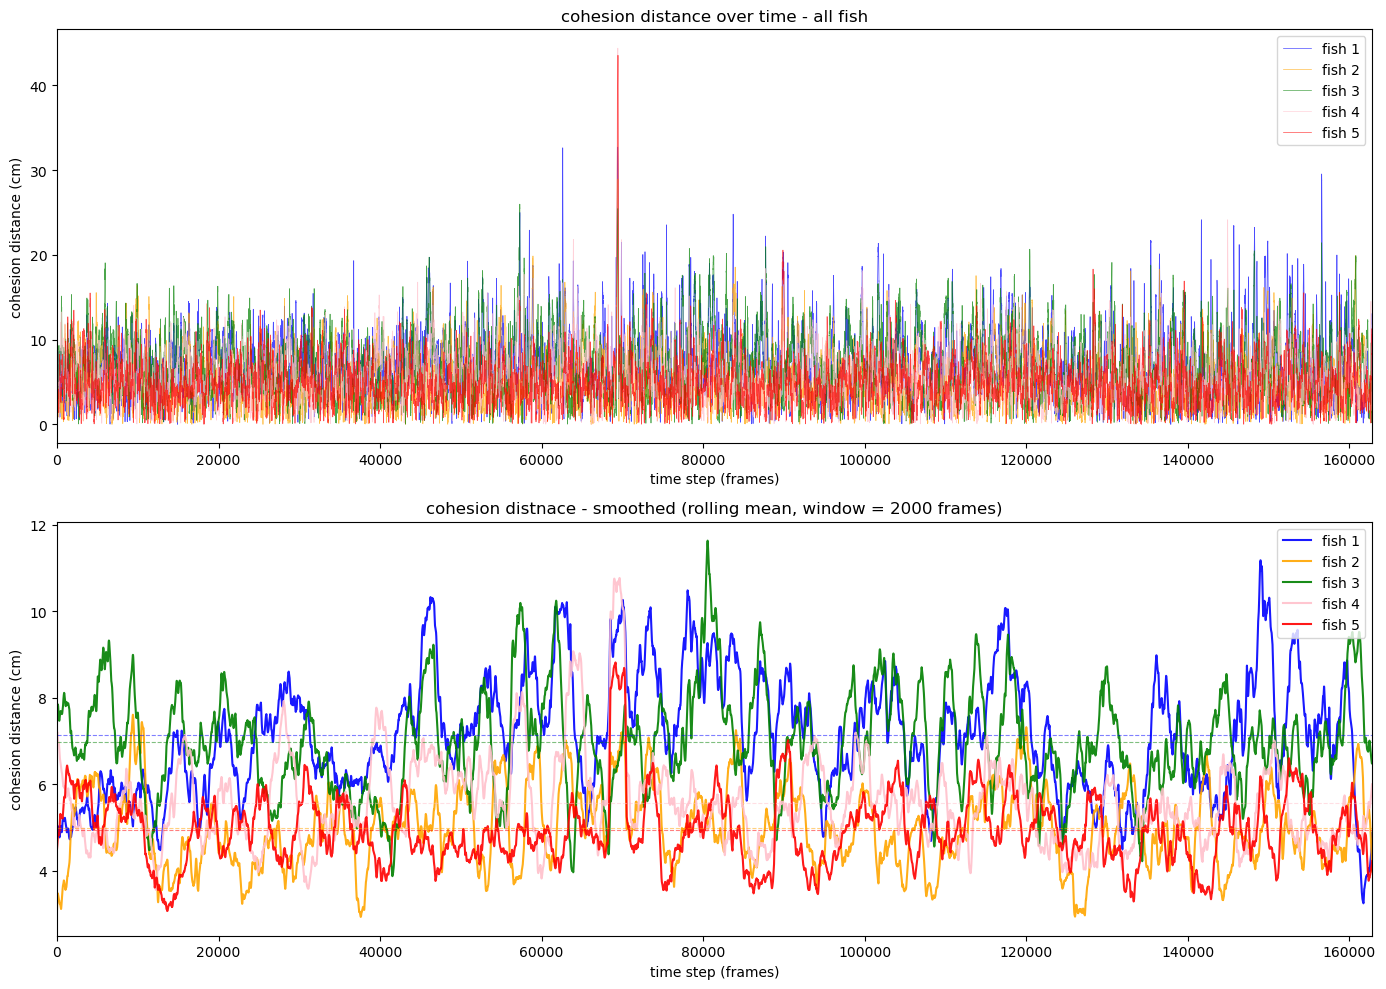

In [33]:
colours = ['blue', 'orange', 'green', 'pink', 'red']
windows = [100, 500, 1000, 2000]

for w in windows:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    for f in range(n_fish):
        axes[0].plot(cohesion_distance_cm[:, f], label=f'fish {f+1}', color=colours[f], lw=0.5, alpha=0.7)

    axes[0].set_title('cohesion distance over time - all fish')
    axes[0].set_xlabel('time step (frames)')
    axes[0].set_ylabel('cohesion distance (cm)')
    axes[0].legend(loc='upper right')
    axes[0].set_xlim(0, len(cohesion_distance_cm))

    for f in range(n_fish):
        series = pd.Series(cohesion_distance_cm[:, f])
        smoothed = series.rolling(window=w, center=True, min_periods=1).mean()
        axes[1].plot(smoothed, label=f'fish {f+1}', color=colours[f], lw=1.5, alpha=0.9)

    axes[1].set_title(f'cohesion distnace - smoothed (rolling mean, window = {w} frames)')
    axes[1].set_xlabel('time step (frames)')
    axes[1].set_ylabel('cohesion distance (cm)')
    axes[1].legend(loc='upper right')
    axes[1].set_xlim(0, len(cohesion_distance_cm))

    # adding mean lines 
    for f in range(n_fish):
        mean_val = np.nanmean(cohesion_distance_cm[:, f])
        axes[1].axhline(y=mean_val, color=colours[f], linestyle='--', lw=0.8, alpha=0.5)

    plt.tight_layout()
    plt.show()

These plots show the cohesion diatance for each fish at each time frame. 

Top plot:
* Noisy - shows every single frame
* Mostly the fish sit between 0-15cm from their neighbourhood centre - normal schooling behaiviour
* Large spikes are probably tracking errors 
* Fish 3 (green) has the most dramatic spikes - lots more nan points in the data 

Bottom plot:
* Averaged out the noise by different ammoutns - windows = 2000 is most accurate

Dashed horizontal lines show the mean cohesion of each fish. 